### Imports and Configuration

In [1]:
from pipeline_utils import make_case1_paths
import pandas as pd
import numpy as np

# Configure paths
paths = make_case1_paths()

PROJECT_DIR = paths["project"]
RAW_DIR = paths["raw_uhn"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Input files
breast_fold_results = PROC_DIR / "growth_ml_fold_results_breast.csv"
breast_pred_results = PROC_DIR / "growth_ml_predictions_breast.csv"
breast_dt_rna_file = PROC_DIR / "rna_doubling_time_merged_breast.csv"

lung_fold_results = PROC_DIR / "growth_ml_fold_results_lung.csv"
lung_pred_results = PROC_DIR / "growth_ml_predictions_lung.csv"
lung_dt_rna_file = PROC_DIR / "rna_doubling_time_merged_lung.csv"

df_results_breast = pd.read_csv(breast_fold_results)
df_preds_breast = pd.read_csv(breast_pred_results)
df_dt_rna_breast = pd.read_csv(breast_dt_rna_file, index_col=0)

df_results_lung = pd.read_csv(lung_fold_results)
df_preds_lung = pd.read_csv(lung_pred_results)
df_dt_rna_lung = pd.read_csv(lung_dt_rna_file, index_col=0)

print(f"breast ML results file: {breast_fold_results}")
print(f"breast ML prediction file: {breast_pred_results}")
print(f"breast ML input file: {breast_dt_rna_file}")
print(f"lung ML results file: {lung_fold_results}")
print(f"lung ML prediction file: {lung_pred_results}")
print(f"lung ML input file: {lung_dt_rna_file}")

# Output files
roc_compare_plot = RESULTS_DIR / "figure2e_Model_Comparison.png"
roc_plot = RESULTS_DIR / "figure2f_ROC.png"
shap_breast_plot = RESULTS_DIR / "Figure2_SHAP_Compact_breast.png"
shap_breast_output = RESULTS_DIR / "SHAP_Global_Gene_Importance_breast.csv"
shap_lung_plot = RESULTS_DIR / "Figure2_SHAP_Compact_lung.png"
shap_lung_output = RESULTS_DIR / "SHAP_Global_Gene_Importance_lung.csv"


/Users/guanqiaofeng/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Raw data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate


breast ML results file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_fold_results_breast.csv
breast ML prediction file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_predictions_breast.csv
breast ML input file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_breast.csv
lung ML results file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_fold_results_lung.csv
lung ML prediction file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_predictions_lung.csv
lung ML input file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_lung.csv


### Model performance barplot

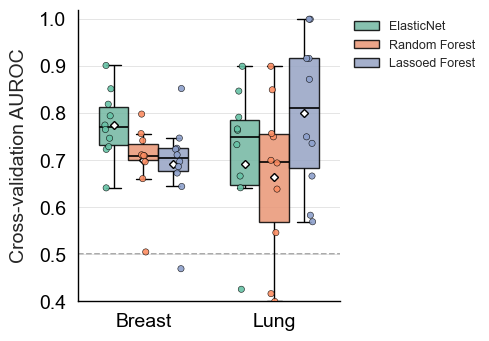

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Summarize fold AUROCs within each CV repeat before plotting
dataset_specs = {
    "Breast": {"results": df_results_breast, "n_splits": 5},
    "Lung": {"results": df_results_lung, "n_splits": 3},
}
model_names = ["ElasticNet", "RandomForest", "LassoedForest"]
model_labels = {
    "ElasticNet": "ElasticNet",
    "RandomForest": "Random Forest",
    "LassoedForest": "Lassoed Forest",
}
model_colors = {
    "ElasticNet": "#66c2a5",
    "RandomForest": "#fc8d62",
    "LassoedForest": "#8da0cb",
}

repeat_results = []
for dataset_name, spec in dataset_specs.items():
    tmp = spec["results"].loc[
        spec["results"]["Model"].isin(model_names),
        ["Model", "Fold", "AUROC"],
    ].dropna().copy()
    tmp["Repeat"] = ((tmp["Fold"].astype(int) - 1) // spec["n_splits"]) + 1
    tmp = tmp.groupby(["Repeat", "Model"], as_index=False)["AUROC"].mean()
    tmp["Dataset"] = dataset_name
    repeat_results.append(tmp)

plot_df = pd.concat(repeat_results, ignore_index=True)
plot_df["Model label"] = plot_df["Model"].map(model_labels)
palette = {model_labels[m]: model_colors[m] for m in model_names}
dataset_order = list(dataset_specs)
hue_order = [model_labels[m] for m in model_names]

# Nature-style box plots with every repeat-level value visible
sns.set_theme(style="whitegrid", context="paper", font="Arial")
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(
    data=plot_df, x="Dataset", y="AUROC", hue="Model label",
    order=dataset_order, hue_order=hue_order, palette=palette,
    width=0.68, linewidth=1.0, showfliers=False, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white",
               "markeredgecolor": "black", "markersize": 4},
    boxprops={"edgecolor": "black", "linewidth": 1.0, "alpha": 0.85},
    whiskerprops={"color": "black", "linewidth": 1.0},
    capprops={"color": "black", "linewidth": 1.0},
    medianprops={"color": "black", "linewidth": 1.2}, ax=ax,
)
sns.stripplot(
    data=plot_df, x="Dataset", y="AUROC", hue="Model label",
    order=dataset_order, hue_order=hue_order, palette=palette,
    dodge=True, jitter=0.08, size=4.5, alpha=0.9,
    edgecolor="black", linewidth=0.4, legend=False, ax=ax, zorder=3,
)

ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.1,
           alpha=0.8, zorder=0)
ax.set_xlabel("")
ax.set_ylabel("Cross-validation AUROC", fontsize=14, labelpad=8)
ax.tick_params(axis="x", labelsize=14, colors="black", width=1.0)
ax.tick_params(axis="y", labelsize=14, colors="black", width=1.0)
ax.set_ylim(0.4, 1.02)
ax.legend(title="", loc="upper left", bbox_to_anchor=(1.01, 1.0),
          fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(roc_compare_plot, dpi=300, bbox_inches="tight")
plt.show()

### Model performance summary table

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

# Per-fold performance summary (AUROC, Spearman, Pearson) for each classifier x cohort,
# plus a one-sample t-test of AUROC against chance (0.5). Same test -- and the same
# "repeated-CV folds are not fully independent" caveat -- used for the AUROCs reported
# in the case study 4 (paclitaxel) results; kept consistent across case studies.
dataset_specs = {
    "Breast": df_results_breast,
    "Lung": df_results_lung,
}
model_names = ["ElasticNet", "RandomForest", "LassoedForest"]
model_labels = {
    "ElasticNet": "ElasticNet",
    "RandomForest": "Random Forest",
    "LassoedForest": "Lassoed Forest",
}

summary_rows = []
for cohort, df in dataset_specs.items():
    for model in model_names:
        g = df.loc[df["Model"] == model]
        auroc = g["AUROC"].dropna()
        t_stat, p_value = stats.ttest_1samp(auroc, popmean=0.5)
        summary_rows.append({
            "Cohort": cohort,
            "Model": model_labels[model],
            "n_folds": int(auroc.count()),
            "AUROC_mean": auroc.mean(),
            "AUROC_sd": auroc.std(ddof=0),
            "AUROC_t_stat_vs_chance": t_stat,
            "AUROC_p_value_vs_chance": p_value,
            "Spearman_mean": g["Spearman"].mean(),
            "Spearman_sd": g["Spearman"].std(ddof=0),
            "Pearson_mean": g["Pearson"].mean(),
            "Pearson_sd": g["Pearson"].std(ddof=0),
        })

performance_summary = pd.DataFrame(summary_rows)
performance_summary_file = RESULTS_DIR / "growth_ml_performance_summary.csv"
performance_summary.to_csv(performance_summary_file, index=False)

print(f"Saved model performance summary (mean +/- population SD across completed folds; "
      f"AUROC one-sample t-test vs. chance = 0.5) to {performance_summary_file}")
performance_summary

Saved model performance summary (mean +/- population SD across completed folds; AUROC one-sample t-test vs. chance = 0.5) to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/growth_ml_performance_summary.csv


,Cohort,Model,n_folds,AUROC_mean,AUROC_sd,AUROC_t_stat_vs_chance,AUROC_p_value_vs_chance,Spearman_mean,Spearman_sd,Pearson_mean,Pearson_sd
0,Breast,ElasticNet,50,0.774933,0.172884,11.131944,5.084589e-15,0.432381,0.259735,0.457614,0.281523
1,Breast,Random Forest,50,0.700194,0.186079,7.530983,1.002651e-09,0.313239,0.283336,0.375930,0.266667
2,Breast,Lassoed Forest,50,0.693253,0.177896,7.604293,7.731187e-10,0.281194,0.270611,0.327233,0.271898
3,Lung,ElasticNet,30,0.692593,0.233191,4.447602,1.173447e-04,0.295397,0.410998,0.398695,0.385011
4,Lung,Random Forest,30,0.665324,0.247278,3.600391,1.169638e-03,0.257431,0.463332,0.339521,0.441527
5,Lung,Lassoed Forest,30,0.801111,0.252155,6.430701,4.921761e-07,0.450194,0.356802,0.494712,0.401646


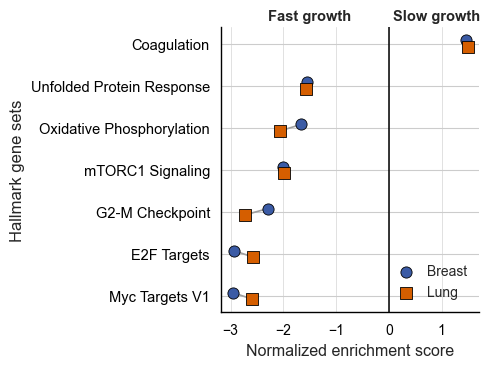

,Pathway,NES_breast,FDR_breast,NES_lung,FDR_lung
0,Myc Targets V1,-2.951381,0.000000,-2.600455,0.000000
1,E2F Targets,-2.942198,0.000000,-2.581543,0.000000
2,G2-M Checkpoint,-2.294026,0.000000,-2.724964,0.000000
3,mTORC1 Signaling,-2.001375,0.000578,-1.982657,0.000087
4,Oxidative Phosphorylation,-1.663710,0.007770,-2.053634,0.000091
5,Unfolded Protein Response,-1.543758,0.018224,-1.564774,0.012562
6,Coagulation,1.467042,0.038746,1.493797,0.037032


Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/growth_gsea_cross_cohort_concordance.csv
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure3_Main_Shared_Hallmark_NES.png
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/growth_gsea_figure2e_hallmark_concordant.csv


In [4]:
# Main-figure panel: pathways concordantly enriched in breast and lung PDXs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

concordance_file = RESULTS_DIR / "growth_gsea_cross_cohort_concordance.csv"
shared_pathways = pd.read_csv(concordance_file)

# Hallmark is used for the main panel because it is compact and less redundant than GO.
# Selection is objective: same NES direction and FDR < 0.05 in both cohorts.
main_pathways = shared_pathways.loc[
    (shared_pathways["Collection"] == "MSigDB Hallmark")
    & shared_pathways["direction_concordant"].astype(bool)
    & (shared_pathways["FDR_breast"] < 0.05)
    & (shared_pathways["FDR_lung"] < 0.05)
].copy()
if main_pathways.empty:
    raise ValueError("No concordant Hallmark pathways pass FDR < 0.05 in both cohorts")

main_pathways["mean_NES"] = main_pathways[["NES_breast", "NES_lung"]].mean(axis=1)
main_pathways = main_pathways.sort_values("mean_NES", ascending=True).reset_index(drop=True)
main_pathways["Pathway"] = (
    main_pathways["Term"].str.replace("HALLMARK_", "", regex=False)
    .str.replace("_", " ", regex=False)
)

y_position = np.arange(len(main_pathways))
breast_color = "#3B5BA5"
lung_color = "#D55E00"
fast_color = "#f62c4a"
slow_color = "#0072B2"

fig, ax = plt.subplots(figsize=(5, 4))
marker_offset = 0.075
for y, breast_nes, lung_nes in zip(
    y_position, main_pathways["NES_breast"], main_pathways["NES_lung"]
):
    ax.plot(
        [breast_nes, lung_nes], [y + marker_offset, y - marker_offset], color="#9E9E9E",
        linewidth=1.2, zorder=1,
    )

ax.scatter(
    main_pathways["NES_breast"], y_position + marker_offset, s=65, marker="o",
    color=breast_color, edgecolor="black", linewidth=0.6, label="Breast", zorder=3,
)
ax.scatter(
    main_pathways["NES_lung"], y_position - marker_offset, s=65, marker="s",
    color=lung_color, edgecolor="black", linewidth=0.6, label="Lung", zorder=3,
)
ax.axvline(0, color="black", linewidth=1.1, zorder=2)
ax.set_yticks(y_position)
ax.set_yticklabels(main_pathways["Pathway"], fontsize=10.5)
ax.set_xlabel("Normalized enrichment score", fontsize=11.5)
# ax.set_title("Shared Hallmark pathway enrichment", fontsize=14, pad=22)
ax.text(
    0.18, 1.015, "Fast growth", transform=ax.transAxes,
    ha="left", va="bottom", fontsize=10.5, fontweight="bold",
)
ax.text(
    1.005, 1.015, "Slow growth", transform=ax.transAxes,
    ha="right", va="bottom", fontsize=10.5, fontweight="bold",
)
ax.legend(loc="lower right", frameon=False, fontsize=10, handletextpad=0.5)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.tick_params(axis="x", labelsize=10, colors="black")
ax.tick_params(axis="y", colors="black")
ax.set_ylabel("Hallmark gene sets", fontsize=12)

# fig.text(
#     0.5, 0.012, "Concordant direction; FDR < 0.05 in both cohorts",
#     ha="center", va="bottom", fontsize=8.5, color="#555555",
# )
plt.tight_layout(rect=[0, 0.055, 1, 1])
main_pathway_plot = RESULTS_DIR / "Figure3_Main_Shared_Hallmark_NES.png"
plt.savefig(main_pathway_plot, dpi=600, bbox_inches="tight")
plt.savefig(main_pathway_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

main_pathways_table = main_pathways[[
    "Pathway", "NES_breast", "FDR_breast", "NES_lung", "FDR_lung"
]]
main_pathways_file = RESULTS_DIR / "growth_gsea_figure2e_hallmark_concordant.csv"
main_pathways_table.to_csv(main_pathways_file, index=False)

display(main_pathways_table)
print(f"Loaded {concordance_file}")
print(f"Saved {main_pathway_plot}")
print(f"Saved {main_pathways_file}")
